# Pre-processing 





## 1. Importer les données

In [258]:
import pandas as pd
from IPython.display import display
import polars as pl

In [259]:
# Téléchargement des dataframes depuis la base de données des BAAC.
urls_y = {
    2022: {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/5fc299c0-4598-4c29-b74c-6a67b0cc27e7",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/a6ef711a-1f03-44cb-921a-0ce8ec975995",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/62c20524-d442-46f5-bfd8-982c59763ec8"
    },
    2023 : {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/104dbb32-704f-4e99-a71e-43563cb604f2",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/8bef19bf-a5e4-46b3-b5f9-a145da4686bc",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/68848e2a-28dd-4efc-9d5f-d512f7dbe66f"
    },
    2024 : {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/83f0fb0e-e0ef-47fe-93dd-9aaee851674a",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/228b3cda-fdfb-4677-bd54-ab2107028d2d",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/f57b1f58-386d-4048-8f78-2ebe435df868"
    }
}

url_05_21 = {
    "carac" : "https://www.data.gouv.fr/api/1/datasets/r/a3cac8bc-4a07-4124-8a08-633a3a91d40b",
    "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/b7f25e45-de32-4801-b0eb-62989f1a7406",
    "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/a64b1b9f-4d56-4b26-ae90-9f40b878e109"
}

# Dictionnaire qui contiendra les dataframes pour chaque année en vue de la concaténation

dfs = {}

yrl = [2022,2023,2024]
names = ["carac","lieux","usagers"]

for name in names:
    list_df = []
    for yr in yrl:
        url = urls_y[yr][name]
        df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"
        df_yr.insert(1,"year",yr) # Colonne année pour distinguer les accidents entre années en vue des opérations de fusion de dataframes
        list_df.append(df_yr)

    concatenated_df_type = pd.concat(list_df,ignore_index=True) # On fait fi de l'index
    dfs[name] = concatenated_df_type # On associe le dataframe des trois années au type de dataframe

dfs

# Prend environ 40 secondes à tourner

C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\4211296108.py:37: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"
C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\4211296108.py:37: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"


{'carac':          Accident_Id  year  jour  mois    an   hrmn  lum dep    com  agg  int  \
 0       2.022000e+11  2022    19    10  2022  16:15    1  26  26198    2    3   
 1       2.022000e+11  2022    20    10  2022  08:34    1  25  25204    2    3   
 2       2.022000e+11  2022    20    10  2022  17:15    1  22  22360    2    6   
 3       2.022000e+11  2022    20    10  2022  18:00    1  16  16102    2    3   
 4       2.022000e+11  2022    19    10  2022  11:45    1  13  13103    1    1   
 ...              ...   ...   ...   ...   ...    ...  ...  ..    ...  ...  ...   
 164521           NaN  2024    10     7  2024  02:05    5  94  94065    2    3   
 164522           NaN  2024    30    11  2024  15:27    1  92  92062    2    1   
 164523           NaN  2024    24    10  2024  20:40    3  29  29068    1    1   
 164524           NaN  2024    30    11  2024  15:40    1  92  92012    2    1   
 164525           NaN  2024    10     7  2024  08:30    1  94  94028    2    1   
 
     

## 2. Créer un dataframe pour 2022-2024 regroupant les donneés "Lieux", "Usagers", "Caractéristiques"

In [260]:
if "an" in dfs["carac"].columns:
    dfs["carac"].drop(columns=["an"],inplace=True) # Colonne an redondante avec colonne year

In [261]:
if "Accident_Id" in dfs["carac"].columns:
    dfs["carac"]["Num_Acc"] = dfs["carac"]["Num_Acc"].fillna(dfs["carac"]["Accident_Id"])   # On fusionne Accident_Id et Num_Acc, qui représentent le même indicateur
    dfs["carac"].drop(columns=["Accident_Id"],inplace=True)

col_data = dfs["carac"].pop("Num_Acc")
dfs["carac"].insert(0,"Num_Acc",col_data) # On replace la colonne "Num_Acc" en index 0 des colonnes du dataframe

#### Analyses préliminaires

In [262]:
for n,content in dfs.items(): 
    print(n,len(content))

carac 164526
lieux 196410
usagers 377638


In [263]:
sum(dfs["carac"]["Num_Acc"].value_counts()>1)

0

Dans "carac" il n'y a bien qu'une ligne par accident. 
Il est normal que le dataframe "usagers" soit le plus long : en effet, pour chaque accident corporel, on peut compter plusieurs victimes. Il est plus surprenant que "lieux" soit plus long que "carac". 
Observons les doublons :

In [264]:
dfs["lieux"]["Num_Acc"].value_counts()

Num_Acc
202300035508    5
202400050330    5
202300039940    4
202300034748    4
202300006227    4
               ..
202200000042    1
202200000043    1
202200000044    1
202200000045    1
202200000006    1
Name: count, Length: 164526, dtype: int64

In [265]:
dfs["lieux"][dfs["lieux"]["Num_Acc"]==202300035508]

,Num_Acc,year,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
101231,202300035508,2023,4,BOULEVARD DE BEAUSEJOUR,0,NaN,1,0,0,1,0,0,1,NaN,-1,1,0,1,30
101232,202300035508,2023,4,BOULEVARD EMILE AUGIER,0,NaN,3,2,0,1,-1,-1,1,NaN,-1,1,9,1,50
101233,202300035508,2023,4,CHAUSSEE LA MUETTE,0,NaN,3,1,3,1,-1,-1,1,NaN,-1,1,6,1,50
101234,202300035508,2023,4,RUE D ANDIGNE,0,NaN,1,1,0,1,0,0,1,NaN,-1,1,0,1,30
101235,202300035508,2023,4,RUE LARGILLIERE,0,NaN,2,2,0,1,0,0,1,NaN,-1,1,0,1,30


"Lieux" indique les différentes voies liées à l'accident lorsqu'il a eu lieu dans une intersection complexe. Il contient par ailleurs différentes informations sur le lieu de l'accident (type de route **catr**, l'état de la surface **surf**, la vitesse maximale autorisée **vma**).

Les données les plus générales sont les "caractéristiques de l'accident", uniques pour chaque accident. Dans chaque accident, on a des données sur le lieu de l'accident et l'avant-accident qui est différent selon les acteurs impliqués. Enfin, la partie "usagers" comporte des informations sur chacun des usagers impliqués dans l'accident ; c'est le dataset le plus large.

#### Observons "Lieux"

Nous supprimons la colonne voie, qui est bruitée, et peu informative. On supprime donc également v1 et v2, qui donnent l'adresse. On supprime de même les colonnes concernant les bornes kilométriques (pr et pr1)

A contrario, la VMA (vitesse maximale autorisée), la catégorie de route (catr - autoroute, route urbaine...), l'état de la surface (surf - conditions de la route : verglas, pluie, neige), le régime de circulation (circ - bidirectionnel, unidirectionnel,...), le type d'infrastructure (infra - ponts, tunnels ou carrefours), situation de l'accident (situ - où a précisément eu lieu l'accident : sur la chaussée, sur la bande d'arrêt d'urgence,...), sont particulièrement importantes pour notre prédiction.

Les colonnes plan, prof, nbv, lartpc, larrout, vosp, donnent des informations précises sur la configuration des lieux de l'accident. En particulier, prof (topographie), plan (courbure de la route), larrout (largeur de la route) sont très intéressantes.

In [266]:
dfs["lieux"].drop(columns=["voie","v1","v2", "pr", "pr1"], inplace=True)
dfs["lieux"]

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50
1,202200000002,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50
2,202200000003,2022,3,-1,2,0,1,1,NaN,-1,1,5,1,50
3,202200000004,2022,4,1,1,0,2,1,NaN,4,1,0,1,30
4,202200000005,2022,3,2,2,0,1,1,NaN,-1,1,0,1,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,2024,3,1,1,-1,1,1,NaN,-1,2,5,4,-1
196406,202400054399,2024,3,1,1,2,1,2,NaN,-1,1,0,1,30
196407,202400054400,2024,2,1,2,0,2,1,NaN,10,1,0,1,110
196408,202400054401,2024,3,2,3,0,1,1,NaN,"10,5",1,0,1,50


In [267]:
dfs["lieux"][dfs["lieux"]["Num_Acc"]==202300000001]

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,1,2,0,1,1,NaN,-1,2,0,1,30
55303,202300000001,2023,4,1,1,0,1,1,NaN,-1,2,0,1,30


Retirons maintenant les doublons.

In [268]:
# Garde uniquement la première occurrence de chaque Num_Acc
dfs["lieux"] = dfs["lieux"].drop_duplicates(subset=["Num_Acc"], keep='first')

In [269]:
dfs["lieux"][dfs["lieux"]["Num_Acc"]==202300000001]

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,1,2,0,1,1,NaN,-1,2,0,1,30


#### Observons "Usagers"

Nous supprimons la colonne id_usager ainsi que id_véhicule et num_véhicule, car nous ne nous attarderons pas sur l'analyse des véhicules et nous avons déjà Num_Acc pour identifier les accidents.

In [270]:
dfs["usagers"].drop(columns=["id_usager","id_vehicule","num_veh"], inplace=True)
dfs["usagers"]

,Num_Acc,year,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202200000001,2022,1,1,3,1,2008.0,5,2,8,-1,-1,-1,-1
1,202200000001,2022,1,1,1,1,1948.0,5,1,8,-1,-1,-1,-1
2,202200000002,2022,1,1,4,1,1988.0,9,1,0,-1,0,0,-1
3,202200000002,2022,1,1,1,1,1970.0,4,1,0,-1,0,0,-1
4,202200000003,2022,1,1,1,1,2002.0,0,1,0,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,2024,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1
377634,202400054401,2024,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1
377635,202400054402,2024,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1
377636,202400054402,2024,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1


#### Observons "Caractéristiques"

Nous pouvons enlever la colonne "adr" car nous avons déjà la latitude et la longitude. Pour la même raison, nous pouvons retirer "dep" et "com", mais nous les gardons de coté si jamais nous souhaitons faire une analyse en fonction des départements et des communes plus tard.

In [271]:
df_geo_backup_2224 = dfs["carac"][["Num_Acc", "year", "dep", "com"]].copy()
dfs["carac"].drop(columns=["dep","com","adr"], inplace=True) 
dfs["carac"]

,Num_Acc,year,jour,mois,hrmn,lum,agg,int,atm,col,lat,long
0,2.022000e+11,2022,19,10,16:15,1,2,3,1,3,"44,5594200000","4,7257200000"
1,2.022000e+11,2022,20,10,08:34,1,2,3,1,3,"46,9258100000","6,3462000000"
2,2.022000e+11,2022,20,10,17:15,1,2,6,1,2,"48,4931620000","-2,7604390000"
3,2.022000e+11,2022,20,10,18:00,1,2,3,8,6,"45,6926520000","-0,3262900000"
4,2.022000e+11,2022,19,10,11:45,1,1,1,1,2,"43,6755790366","5,0927031775"
...,...,...,...,...,...,...,...,...,...,...,...,...
164521,2.024001e+11,2024,10,7,02:05,5,2,3,2,6,"48,75740000","2,34469000"
164522,2.024001e+11,2024,30,11,15:27,1,2,1,1,6,"48,88694322","2,24863619"
164523,2.024001e+11,2024,24,10,20:40,3,1,1,1,1,"48,52619024","-3,96317650"
164524,2.024001e+11,2024,30,11,15:40,1,2,1,1,3,"48,83286197","2,24394009"


#### Fusionner 2022, 2023 et 2024

Créons maintenant un premier dataset, qui fusionne les données de 2022,2023, et 2024 pour les dataframes **usagers** et **carac** :

In [272]:
KEY = ["year","Num_Acc"]

df_final2224 = dfs["usagers"].merge(dfs["carac"],on=KEY,how="left") # On garde toutes les colonnes usagers

print(df_final2224.shape[0]==dfs["usagers"].shape[0])

# df_final2224 et dfs["usagers"] font bien la même longueur.

True


Ajoutons-y les données sur les lieux. 

In [273]:
df_final2224 = df_final2224.merge(dfs["lieux"],on=KEY,how="left") 


In [274]:
df_final2224

,Num_Acc,year,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,...,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,2022,1,1,3,1,2008.0,5,2,8,...,2,0,1,1,NaN,-1,1,0,1,50
1,202200000001,2022,1,1,1,1,1948.0,5,1,8,...,2,0,1,1,NaN,-1,1,0,1,50
2,202200000002,2022,1,1,4,1,1988.0,9,1,0,...,2,0,1,1,NaN,-1,1,0,1,50
3,202200000002,2022,1,1,1,1,1970.0,4,1,0,...,2,0,1,1,NaN,-1,1,0,1,50
4,202200000003,2022,1,1,1,1,2002.0,0,1,0,...,2,0,1,1,NaN,-1,1,5,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,2024,1,1,4,2,1978.0,0,0,0,...,3,0,1,1,NaN,"10,5",1,0,1,50
377634,202400054401,2024,1,1,1,1,1984.0,0,2,6,...,3,0,1,1,NaN,"10,5",1,0,1,50
377635,202400054402,2024,1,1,4,1,1981.0,4,1,0,...,2,0,2,1,NaN,-1,1,2,1,50
377636,202400054402,2024,1,1,4,2,1986.0,9,1,0,...,2,0,2,1,NaN,-1,1,2,1,50


In [275]:
sum(df_final2224["grav"].isna())

0

In [276]:
df_final2224

,Num_Acc,year,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,...,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,2022,1,1,3,1,2008.0,5,2,8,...,2,0,1,1,NaN,-1,1,0,1,50
1,202200000001,2022,1,1,1,1,1948.0,5,1,8,...,2,0,1,1,NaN,-1,1,0,1,50
2,202200000002,2022,1,1,4,1,1988.0,9,1,0,...,2,0,1,1,NaN,-1,1,0,1,50
3,202200000002,2022,1,1,1,1,1970.0,4,1,0,...,2,0,1,1,NaN,-1,1,0,1,50
4,202200000003,2022,1,1,1,1,2002.0,0,1,0,...,2,0,1,1,NaN,-1,1,5,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,2024,1,1,4,2,1978.0,0,0,0,...,3,0,1,1,NaN,"10,5",1,0,1,50
377634,202400054401,2024,1,1,1,1,1984.0,0,2,6,...,3,0,1,1,NaN,"10,5",1,0,1,50
377635,202400054402,2024,1,1,4,1,1981.0,4,1,0,...,2,0,2,1,NaN,-1,1,2,1,50
377636,202400054402,2024,1,1,4,2,1986.0,9,1,0,...,2,0,2,1,NaN,-1,1,2,1,50


La gravité des blessures de chaque victime est renseignée, ce qui nous évite un travail supplémentaire de preprocessing pour la variable d'intérêt **grav**.

>Pour rappel, **grav** peut prendre quatre valeurs : 
>* 1 = Indemne
>* 2 = Tué
>* 3 = Blessé hospitalisé
>* 4 = Blessé léger
    

## 3. Créer un dataframe pour 2005-2021 regroupant les donneés "Lieux", "Usagers", "Caractéristiques"

#### Créer df0521

In [277]:
url_05_21.items()

dict_items([('carac', 'https://www.data.gouv.fr/api/1/datasets/r/a3cac8bc-4a07-4124-8a08-633a3a91d40b'), ('lieux', 'https://www.data.gouv.fr/api/1/datasets/r/b7f25e45-de32-4801-b0eb-62989f1a7406'), ('usagers', 'https://www.data.gouv.fr/api/1/datasets/r/a64b1b9f-4d56-4b26-ae90-9f40b878e109')])

Nous construisons maintenant le dataset contenant les données de 2005 à 2021 en vue d'une harmonisation

In [278]:
df0521={}
for type,link in url_05_21.items():
    df0521[type] = pd.read_csv(link,
                               encoding="latin-1",  # Old files, with a different encoding than the recent ones
                               sep=",")
df0521

# Prend environ 2 min 30 à tourner

C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\3640247353.py:3: DtypeWarning: Columns (4,10,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df0521[type] = pd.read_csv(link,
C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\3640247353.py:3: DtypeWarning: Columns (3,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df0521[type] = pd.read_csv(link,
C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\3640247353.py:3: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df0521[type] = pd.read_csv(link,


{'carac':          Unnamed: 0       num_acc  mois  jour   hrmn  lum  agg  int  atm  col  \
 0                 1  200500000001     1    12   1900    3    2    1  1.0  3.0   
 1                 2  200500000002     1    21   1600    1    2    1  1.0  1.0   
 2                 3  200500000003     1    21   1845    3    1    1  2.0  1.0   
 3                 4  200500000004     1     4   1615    1    1    1  1.0  5.0   
 4                 5  200500000005     1    10   1945    3    1    1  3.0  6.0   
 ...             ...           ...   ...   ...    ...  ...  ...  ...  ...  ...   
 1121566     1121567  202100056514     1     1  06:10    3    1    1  5.0  6.0   
 1121567     1121568  202100056515     1     1  10:20    1    1    1  2.0  6.0   
 1121568     1121569  202100056516     1     1  18:00    3    1    1  2.0  1.0   
 1121569     1121570  202100056517     1     1  10:55    1    1    2  1.0  6.0   
 1121570     1121571  202100056518     1     2  18:00    3    1    1  3.0  1.0   
 
     

#### Harmonisation préliminaire

On supprime la colonne redondante d'index "Unnamed: 0" (liée au format d'importation) et on renomme les colonnes "num_acc" et "annee" pour être en cohérence avec le dataset df_final2224 :

In [279]:
for type in ["usagers","carac"]:
    df0521[type]=df0521[type].rename(columns={"annee":"year","num_acc":"Num_Acc"})
    if "Unnamed: 0" in df0521[type].columns:
        df0521[type].drop(columns="Unnamed: 0",inplace=True)

df0521


{'carac':               Num_Acc  mois  jour   hrmn  lum  agg  int  atm  col    com  \
 0        200500000001     1    12   1900    3    2    1  1.0  3.0     11   
 1        200500000002     1    21   1600    1    2    1  1.0  1.0     51   
 2        200500000003     1    21   1845    3    1    1  2.0  1.0     51   
 3        200500000004     1     4   1615    1    1    1  1.0  5.0     82   
 4        200500000005     1    10   1945    3    1    1  3.0  6.0    478   
 ...               ...   ...   ...    ...  ...  ...  ...  ...  ...    ...   
 1121566  202100056514     1     1  06:10    3    1    1  5.0  6.0  33021   
 1121567  202100056515     1     1  10:20    1    1    1  2.0  6.0  38405   
 1121568  202100056516     1     1  18:00    3    1    1  2.0  1.0  26064   
 1121569  202100056517     1     1  10:55    1    1    2  1.0  6.0  33003   
 1121570  202100056518     1     2  18:00    3    1    1  3.0  1.0  78423   
 
                                adr gps            lat           

In [280]:
df0521["lieux"]=df0521["lieux"].rename(columns={"annee":"year","num_acc":"Num_Acc"})
if "Unnamed: 0" in df0521["lieux"].columns:
    df0521["lieux"].drop(columns="Unnamed: 0",inplace=True)

#### Supprimer les colonnes inutiles

Maintenant, nous enlevons les mêmes colonnes que nous avions enlevées dans dfs. 

In [281]:
df0521["lieux"].drop(columns=["voie","v1","v2", "pr", "pr1", "env1"], inplace=True) #en1 n'est que présente entre 2005 et 2021 et signifie la proximité avec une école
df0521["usagers"].drop(columns=["num_veh", "id_vehicule"], inplace=True)
df0521["carac"].drop(columns=["dep","com","adr", "gps"], inplace=True) #gps n'est pas présent dans les données 2022-2024, et nous pouvons la supprimer car nous avons long et lat
df0521


{'carac':               Num_Acc  mois  jour   hrmn  lum  agg  int  atm  col  \
 0        200500000001     1    12   1900    3    2    1  1.0  3.0   
 1        200500000002     1    21   1600    1    2    1  1.0  1.0   
 2        200500000003     1    21   1845    3    1    1  2.0  1.0   
 3        200500000004     1     4   1615    1    1    1  1.0  5.0   
 4        200500000005     1    10   1945    3    1    1  3.0  6.0   
 ...               ...   ...   ...    ...  ...  ...  ...  ...  ...   
 1121566  202100056514     1     1  06:10    3    1    1  5.0  6.0   
 1121567  202100056515     1     1  10:20    1    1    1  2.0  6.0   
 1121568  202100056516     1     1  18:00    3    1    1  2.0  1.0   
 1121569  202100056517     1     1  10:55    1    1    2  1.0  6.0   
 1121570  202100056518     1     2  18:00    3    1    1  3.0  1.0   
 
                    lat            long  year  
 0            5051500.0        294400.0  2005  
 1            5053700.0        280200.0  2005  
 2   

In [282]:
dfs["lieux"] = dfs["lieux"].drop_duplicates(subset=["Num_Acc"], keep='first')

#### Merge

In [283]:
KEY = ["Num_Acc","year"]
df_final0521 = df0521["usagers"].merge(df0521["carac"],on=KEY,how="left")   # On garde toutes les données de "usagers", qui est plus large que "carac".
df_final0521

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,...,mois,jour,hrmn,lum,agg,int,atm,col,lat,long
0,2.005000e+11,1.0,1,4,1,1.0,11.0,0.0,0,0.0,...,1.0,12.0,1900,3.0,2.0,1.0,1.0,3.0,5051500.0,294400.0
1,2.005000e+11,1.0,1,3,2,3.0,11.0,0.0,0,0.0,...,1.0,12.0,1900,3.0,2.0,1.0,1.0,3.0,5051500.0,294400.0
2,2.005000e+11,2.0,2,1,1,0.0,11.0,0.0,0,0.0,...,1.0,12.0,1900,3.0,2.0,1.0,1.0,3.0,5051500.0,294400.0
3,2.005000e+11,4.0,2,1,1,0.0,31.0,0.0,0,0.0,...,1.0,12.0,1900,3.0,2.0,1.0,1.0,3.0,5051500.0,294400.0
4,2.005000e+11,5.0,2,1,1,0.0,11.0,0.0,0,0.0,...,1.0,12.0,1900,3.0,2.0,1.0,1.0,3.0,5051500.0,294400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509615,2.021001e+11,1.0,1,4,1,0.0,NaN,0.0,0,-1.0,...,1.0,1.0,18:00,3.0,1.0,1.0,2.0,1.0,"44,9112100000","5,0196360000"
2509616,2.021001e+11,1.0,1,4,1,5.0,NaN,0.0,0,-1.0,...,1.0,1.0,18:00,3.0,1.0,1.0,2.0,1.0,"44,9112100000","5,0196360000"
2509617,2.021001e+11,1.0,1,3,1,0.0,NaN,0.0,0,-1.0,...,1.0,1.0,10:55,1.0,1.0,2.0,1.0,6.0,"44,9542747363","-0,5179211363"
2509618,2.021001e+11,1.0,1,3,1,3.0,NaN,-1.0,-1,-1.0,...,1.0,2.0,18:00,3.0,1.0,1.0,3.0,1.0,"48,7966700000","2,0505000000"


Refaisons le même travail que précedemment sur Lieux.Remarquons que dans le dataset ancien figure le feature "env1" qui signifie la proximité d'une école, nous pouvons retirer ce feature. 

In [284]:
df_final0521 = df_final0521.merge(df0521["lieux"],on=KEY,how="left") 

In [285]:
df_final0521

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,...,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
0,2.005000e+11,1.0,1,4,1,1.0,11.0,0.0,0,0.0,...,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,NaN
1,2.005000e+11,1.0,1,3,2,3.0,11.0,0.0,0,0.0,...,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,NaN
2,2.005000e+11,2.0,2,1,1,0.0,11.0,0.0,0,0.0,...,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,NaN
3,2.005000e+11,4.0,2,1,1,0.0,31.0,0.0,0,0.0,...,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,NaN
4,2.005000e+11,5.0,2,1,1,0.0,11.0,0.0,0,0.0,...,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509615,2.021001e+11,1.0,1,4,1,0.0,NaN,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2509616,2.021001e+11,1.0,1,4,1,5.0,NaN,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2509617,2.021001e+11,1.0,1,3,1,0.0,NaN,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2509618,2.021001e+11,1.0,1,3,1,3.0,NaN,-1.0,-1,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Concaténer les deux dataframes

Observons les différences dans les noms de colonnes du format des anciens datasets (2005-2021), et des nouveaux datasets (2022-2024).

In [286]:
cols_recentes = set(df_final2224.columns)
cols_anciennes = set(df_final0521.columns)

unique_recent = cols_recentes-cols_anciennes # Soustraire les sets permet de ne garder que les colonnes uniquement présentes en 2022-2024
unique_ancien = cols_anciennes-cols_recentes # Colonnes uniquement présentes en 2005-2021

print(unique_ancien,unique_recent)
print(cols_anciennes,cols_recentes)

{'secu'} set()
{'long', 'year', 'mois', 'secu1', 'catr', 'plan', 'larrout', 'an_nais', 'trajet', 'secu2', 'place', 'col', 'lum', 'locp', 'grav', 'circ', 'etatp', 'int', 'nbv', 'lartpc', 'jour', 'situ', 'vosp', 'agg', 'lat', 'secu', 'catu', 'vma', 'sexe', 'Num_Acc', 'atm', 'actp', 'surf', 'hrmn', 'infra', 'secu3', 'prof'} {'long', 'year', 'mois', 'secu1', 'catr', 'plan', 'larrout', 'an_nais', 'trajet', 'secu2', 'place', 'col', 'lum', 'locp', 'grav', 'circ', 'etatp', 'int', 'nbv', 'lartpc', 'jour', 'situ', 'vosp', 'agg', 'lat', 'vma', 'catu', 'sexe', 'Num_Acc', 'atm', 'actp', 'surf', 'hrmn', 'infra', 'secu3', 'prof'}


#### Analyse de la donnée securité (one-hot encoding)



La colonne "secu" correspond de 2005 à 2021 à un code sur deux caractères : 
- Le premier concerne l'existence d'un équipement de sécurité : 
    1 – Ceinture
    2 – Casque
    3 – Dispositif enfants
    4 – Equipement réfléchissant
    9 – Autre 

- Le second concerne l'utilisation de cet équipement de sécurité :
    1 – Oui
    2 – Non
    3 – Non déterminable

Dans les versions plus récentes, il est question de l'existence ET de l'utilisation d'un équipement de sécurité, jusqu'à trois à la fois (secu1,secu2,secu3):
    -1 – Non renseigné  
    0 – Aucun équipement  
    1 – Ceinture  
    2 – Casque  
    3 – Dispositif enfants  
    4 – Gilet réfléchissant  
    5 – Airbag (2RM/3RM)  
    6 – Gants (2RM/3RM)  
    7 – Gants + Airbag (2RM/3RM)  
    8 – Non déterminable  
    9 – Autre

Notons que les lignes de code ci-dessus suggèreent que "secu" n'est pas dans la base de données 2022-2024, mais que "secu1", "secu2", "secu3" dans dans la base de données 2005-2021. En effet, on peut supposer qu'un effort d'harmonisation des bases a été entamé. 

In [287]:
# regardons si ces colonnes sont toutes vides entre 2005 et 2021 (ce n'est visiblement pas les cas)
print(df_final0521[['secu1', 'secu2', 'secu3']].isna().all())

secu1    False
secu2    False
secu3    False
dtype: bool


In [288]:
# regardons la répartition des valeurs dans ces colonnes
print(df_final0521[['secu1', 'secu2', 'secu3']].apply(pd.Series.value_counts).head(10))

       secu1   secu2   secu3
-1.0    2912  134830  363199
 0.0   28989  146876    1102
 1.0  218344     670      21
 2.0   68650     739       7
 3.0    2384     383       5
 4.0     232    3363      51
 5.0     194    4560      19
 6.0     302   33212     190
 7.0      10     505       8
 8.0   44988   41228     164


In [289]:
# On regarde le nombre de valeurs non-nulles par année pour chaque colonne
verif_secu = df_final0521.groupby('year')[['secu', 'secu1', 'secu2', 'secu3']].count()
print(verif_secu)


        secu   secu1   secu2   secu3
year                                
2005  197498       0       0       0
2006  187084       0       0       0
2007  188457       0       0       0
2008  170960       0       0       0
2009  160953       0       0       0
2010  150001       0       0       0
2011  144045       0       0       0
2012  134397       0       0       0
2013  124695       0       0       0
2014  128151       0       0       0
2015  122244       0       0       0
2016  124062       0       0       0
2017  127071       0       0       0
2018  126040       0       0       0
2019       0  132977  132977  132977
2020       0  105295  105295  105295
2021       0  129153  129153  129153


On constate qu'il y a eu une réforme en 2019. L'harmonisation portera donc sur les données de 2005 à 2018.


Pour cela, nous proposons de supprimer les colonnes "secu1", "secu2", et "secu3" (ainsi que "secu" pour l'ancienne base de données), et à la place mettre 11 colonnes (pour "non renseigné", "aucun équipement", "ceinture", "casque", etc...), dans lequel 1 signifie que l'équiment existe et est utilisé, et 0 signifie qu'il n'existe pas ou n'a pas été utilisé. (Nous effectuons un one-hot encoding)

In [290]:
cols_final = ["secu_-1", "secu_0", "secu_1", "secu_2", "secu_3", "secu_4", "secu_5", "secu_6", "secu_7", "secu_8", "secu_9"]
secu_cols = ["secu1", "secu2", "secu3"]

Regardons le dataframe de 2022 à 2024

In [291]:
# Initialiser les colonnes finales à 0
for col in cols_final:
    df_final2224[col] = 0

# Remplir les colonnes finales
for c in secu_cols:
    dummies = pd.get_dummies(df_final2224[c], prefix='secu')
    for col in dummies.columns:
        df_final2224[col] = df_final2224[col] | dummies[col]

# Supprimer les colonnes originales
df_final2224.drop(columns=secu_cols, inplace=True)


In [292]:
print(df_final2224.columns.tolist())

['Num_Acc', 'year', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'locp', 'actp', 'etatp', 'jour', 'mois', 'hrmn', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4', 'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9']


On fait exactement la même chose sur l'ancienne base de données, en faisant attention à la différence de traitement sur les périodes 2005-2018 et 2019-2021. 

In [293]:
for col in cols_final:
    df_final0521[col] = 0

# De 2019 à 2021 (Nouveau format) 
for c in ["secu1", "secu2", "secu3"]:
    if c in df_final0521.columns:
        for val in [1, 2, 3, 4, 9]: # Les codes équipements
            col_target = f"secu_{val}"
            if col_target in df_final0521.columns:
                # On met 1 si la colonne c contient la valeur val
                df_final0521.loc[df_final0521[c] == val, col_target] = 1

# De2005 à 2018 (Ancien format)
if 'secu' in df_final0521.columns:
    # On isole les lignes d'avant 2019
    mask_old = df_final0521['year'] < 2019
    
    # On convertit en float puis int pour gérer les NaN proprement
    # On travaille sur une copie temporaire pour extraire les chiffres
    s_temp = df_final0521.loc[mask_old, 'secu'].fillna(0).astype(int)
    
    for val in [1, 2, 3, 4, 9]:
        col_target = f"secu_{val}"
        if col_target in df_final0521.columns:
            # condition : le premier chiffre est val et le deuxième chiffre est 1
            # Ex: 11 (ceinture oui) -> 11 // 10 == 1 et 11 % 10 == 1
            cond_equip = (s_temp // 10 == val)
            cond_usage = (s_temp % 10 == 1)
            
            df_final0521.loc[mask_old & cond_equip & cond_usage, col_target] = 1

df_final0521.drop(columns=["secu", "secu1", "secu2", "secu3"], errors='ignore', inplace=True)

In [294]:
print(df_final0521.columns.tolist())

['Num_Acc', 'place', 'catu', 'grav', 'sexe', 'trajet', 'locp', 'actp', 'etatp', 'an_nais', 'year', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4', 'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9']


Vérification

In [295]:
# On vérifie la moyenne de remplissage de secu_1 (ceinture) par année
# Si ça affiche des pourcentages cohérents partout, c'est bon
print("Taux de présence de la ceinture par année :")
print(df_final0521.groupby('year')['secu_1'].mean())
print(df_final2224.groupby('year')['secu_1'].mean())

Taux de présence de la ceinture par année :
year
2005    0.556477
2006    0.542422
2007    0.542469
2008    0.540308
2009    0.548077
2010    0.556358
2011    0.553510
2012    0.558906
2013    0.555605
2014    0.551934
2015    0.586541
2016    0.598769
2017    0.563501
2018    0.595887
2019    0.606481
2020    0.590750
2021    0.586730
Name: secu_1, dtype: float64
year
2022    0.584564
2023    0.581036
2024    0.583335
Name: secu_1, dtype: float64


On peut dire que ces chiffres sont cohérents, donc que le one-hot encoding a marché.

#### re-vérification des colonnes des deux dataframes

Maintenant, revérifions que les dataframes ancien et récent ont bien les mêmes colonnes.

In [296]:
cols_recentes = set(df_final2224.columns)
cols_anciennes = set(df_final0521.columns)

unique_recent = cols_recentes-cols_anciennes # Soustraire les sets permet de ne garder que les colonnes uniquement présentes en 2022-2024
unique_ancien = cols_anciennes-cols_recentes # Colonnes uniquement présentes en 2005-2021

print(unique_ancien,unique_recent)

set() set()


Maintenant que les deux dataframes ont les même colonnes, faisons d'autres vérifications avant de les concaténer. 

In [297]:
#Réorganisons les colonnes par ordre alphabétique pour faciliter la comparaison
df_final0521 = df_final0521.reindex(sorted(df_final0521.columns), axis=1)
df_final2224 = df_final2224.reindex(sorted(df_final2224.columns), axis=1)

In [298]:
print(df_final0521.columns.tolist())
print(df_final2224.columns.tolist())

['Num_Acc', 'actp', 'agg', 'an_nais', 'atm', 'catr', 'catu', 'circ', 'col', 'etatp', 'grav', 'hrmn', 'infra', 'int', 'jour', 'larrout', 'lartpc', 'lat', 'locp', 'long', 'lum', 'mois', 'nbv', 'place', 'plan', 'prof', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4', 'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9', 'sexe', 'situ', 'surf', 'trajet', 'vma', 'vosp', 'year']
['Num_Acc', 'actp', 'agg', 'an_nais', 'atm', 'catr', 'catu', 'circ', 'col', 'etatp', 'grav', 'hrmn', 'infra', 'int', 'jour', 'larrout', 'lartpc', 'lat', 'locp', 'long', 'lum', 'mois', 'nbv', 'place', 'plan', 'prof', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4', 'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9', 'sexe', 'situ', 'surf', 'trajet', 'vma', 'vosp', 'year']


#### Regardons le type des données dans les deux dataframes, et harmonisons les

In [299]:
# Regardons les différents types
for col in df_final0521.columns:
     print(col, df_final0521[col].dtype, df_final2224[col].dtype)


Num_Acc float64 int64
actp object object
agg float64 int64
an_nais float64 float64
atm float64 int64
catr float64 int64
catu int64 int64
circ float64 int64
col float64 int64
etatp float64 int64
grav int64 int64
hrmn object object
infra float64 int64
int float64 int64
jour float64 int64
larrout float64 object
lartpc float64 object
lat object object
locp float64 int64
long object object
lum float64 int64
mois float64 int64
nbv float64 object
place float64 int64
plan float64 int64
prof float64 int64
secu_-1 int64 bool
secu_0 int64 bool
secu_1 int64 bool
secu_2 int64 bool
secu_3 int64 bool
secu_4 int64 bool
secu_5 int64 bool
secu_6 int64 bool
secu_7 int64 bool
secu_8 int64 bool
secu_9 int64 bool
sexe int64 int64
situ float64 int64
surf float64 int64
trajet float64 int64
vma float64 int64
vosp float64 int64
year int64 int64


Voici notre stratégie d'harmonisation:
- On transforme les objet en str (cela concerne : actp, hrmn, lat et long)
- Transformer les int64 en float64 (car le float64 prend en compte les NaN)
- Transformer les bool (donc les données sécu) aussi en float64 (pour avoir le moins de type de données différentes dans le dataframe)


In [300]:
cols_to_str = ['actp', 'hrmn', 'lat', 'long', 'larrout', 'lartpc', 'nbv']

for col in cols_to_str:
    if col in df_final0521.columns:
        df_final0521[col] = df_final0521[col].astype(str)
    if col in df_final2224.columns:
        df_final2224[col] = df_final2224[col].astype(str)

In [301]:
num_cols_0521 = df_final0521.select_dtypes(include=['number', 'bool']).columns
num_cols_2224 = df_final2224.select_dtypes(include=['number', 'bool']).columns

for col in num_cols_0521:
    df_final0521[col] = df_final0521[col].astype(float)

for col in num_cols_2224:
    df_final2224[col] = df_final2224[col].astype(float)

In [302]:
# Vérification finale des types
for col in df_final0521.columns:
    if df_final0521[col].dtype != df_final2224[col].dtype:
        print(col, df_final0521[col].dtype, df_final2224[col].dtype)


C'est bon, les colonnes sont identiques et dans le même ordre, et les valeurs sont de même type, on peut donc concaténer.

In [303]:
df_final = pd.concat([df_final0521, df_final2224], ignore_index=True)


In [304]:
df_final 

,Num_Acc,actp,agg,an_nais,atm,catr,catu,circ,col,etatp,...,secu_7,secu_8,secu_9,sexe,situ,surf,trajet,vma,vosp,year
0,2.005000e+11,0,2.0,1976.0,1.0,3.0,1.0,2.0,3.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,NaN,0.0,2005.0
1,2.005000e+11,0,2.0,1968.0,1.0,3.0,1.0,2.0,3.0,0.0,...,0.0,0.0,0.0,2.0,1.0,1.0,3.0,NaN,0.0,2005.0
2,2.005000e+11,0,2.0,1964.0,1.0,3.0,2.0,2.0,3.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,NaN,0.0,2005.0
3,2.005000e+11,0,2.0,2004.0,1.0,3.0,2.0,2.0,3.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,NaN,0.0,2005.0
4,2.005000e+11,0,2.0,1998.0,1.0,3.0,2.0,2.0,3.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,NaN,0.0,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2887253,2.024001e+11,-1,2.0,1978.0,1.0,3.0,1.0,2.0,3.0,-1.0,...,0.0,0.0,0.0,2.0,1.0,1.0,0.0,50.0,0.0,2024.0
2887254,2.024001e+11,-1,2.0,1984.0,1.0,3.0,1.0,2.0,3.0,-1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,50.0,0.0,2024.0
2887255,2.024001e+11,-1,2.0,1981.0,1.0,3.0,1.0,1.0,4.0,-1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,4.0,50.0,0.0,2024.0
2887256,2.024001e+11,-1,2.0,1986.0,1.0,3.0,1.0,1.0,4.0,-1.0,...,0.0,0.0,0.0,2.0,1.0,1.0,9.0,50.0,0.0,2024.0


In [305]:
print(df_final.columns)


Index(['Num_Acc', 'actp', 'agg', 'an_nais', 'atm', 'catr', 'catu', 'circ',
       'col', 'etatp', 'grav', 'hrmn', 'infra', 'int', 'jour', 'larrout',
       'lartpc', 'lat', 'locp', 'long', 'lum', 'mois', 'nbv', 'place', 'plan',
       'prof', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4',
       'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9', 'sexe', 'situ',
       'surf', 'trajet', 'vma', 'vosp', 'year'],
      dtype='object')


On choisit d'abandonner la colonne 'place' qui précise la position du passager dans le véhicule car elle n'est pas utilie pour notre projet.

In [306]:
df_final.drop(columns=['place'], inplace=True)

## 5. One-hot encoding 


#### agg

In [307]:
print(f"Nombre de NaN dans agg : {df_final['agg'].isna().sum()}")

Nombre de NaN dans agg : 309851


In [308]:
df_final['agg'] = df_final['agg'].fillna(-1.0).replace(0, -1.0)

In [309]:
mapping_agg = {
    -1.0: "agg_non_renseigne",
    1.0: "agg_hors_agglomeration",
    2.0: "agg_en_agglomeration"
}

agg_dummies = pd.get_dummies(df_final['agg'])
agg_dummies = agg_dummies.reindex(mapping_agg.keys(), axis=1, fill_value=0)
agg_dummies = agg_dummies.rename(columns=mapping_agg)

df_final = pd.concat([df_final, agg_dummies], axis=1)
df_final.drop(columns='agg', inplace=True)

In [310]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'circ' OK : {'circ' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='circ_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='circ_').sum(axis=1).mean() == 1.0}")

Suppression 'circ' OK : False
Type bool OK : []
Cohérence lignes OK : False


#### atm

On les cellules vides par un -1.

In [311]:
valeurs_valides = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 9.0]

# Tout ce qui n'est pas dans cette liste devient -1
df_final.loc[~df_final['atm'].isin(valeurs_valides), 'atm'] = -1.0

In [312]:
mapping = {
    -1.0: "atm_Non_renseigné",
     1.0: "atm_Normale",
     2.0: "atm_pluie_légère",
     3.0: "atm_pluie_forte",
     4.0: "atm_neige_grêle",
     5.0: "atm_brouillard_fumée",
     6.0: "atm_vent_fort_tempête",
     7.0: "atm_temps_eblouissant",
     8.0: "atm_temps_couvert",
     9.0: "atm_autre"
}

atm_dummies = pd.get_dummies(df_final['atm'])


atm_dummies = atm_dummies.reindex(columns=mapping.keys(), fill_value=0)

atm_dummies = atm_dummies.rename(columns=mapping).astype(float)

df_final = pd.concat([df_final, atm_dummies], axis=1)
df_final.drop(columns=["atm"], inplace=True)

In [313]:
# Vérification : On regarde si l'atm_Normale est bien la plus fréquente (généralement > 70%)
print(df_final['atm_Normale'].mean())

0.7186164173759324


#### actp

Dans la base de données 2022-2024 apparaissent "-1 - Non renseigné", "A - Monte / Descend du véhicule", "B - Inconnue". 
Nous devons donc remplacer tous les vide ou NaN datant de la période 2005-2021 par des -1, nous allons aussi remplacer tous les B par des -1, et enfin nous allons remplacer tous les A par des 9 qui correspondent à "autre".  Nous remplaçons aussi "0 - Non renseigné ou sans objet" par "-1".
Puis nous ferrons le one-hot encoding.

In [314]:
df_final.loc[df_final['actp'] == 'A', 'actp'] = '9'
df_final.loc[df_final['actp'] == 'B', 'actp'] = '-1'


In [315]:
ratio = (df_final['actp'].isin([0, '0']).sum()) / df_final['actp'].count()
print (ratio)

0.3634150463865716


On voit que la porportion de 0 est assez significative, mais nous les remplacerons tout de même par -1, car cela révèle la même information.

In [316]:
df_final.loc[df_final['actp'] == '0', 'actp'] = '-1'

In [317]:
print(df_final[df_final['year'] == 2010]['actp'].unique())

['0.0' '3.0' '9.0' '1.0' '2.0' '5.0' '4.0' 'nan' '6.0']


On voit qu'il y a un problème de type.

In [318]:
# On unifie tous les types de "vides" vers le code '-1'
vides = ['0', '0.0', 'nan']
df_final['actp'] = df_final['actp'].replace(vides, '-1').fillna('-1')

# On unifie les codes de catégories
df_final['actp'] = df_final['actp'].replace({
    '1.0': '1', '2.0': '2', '3.0': '3', '4.0': '4', '5.0': '5', '6.0': '6', '7.0' : '7', '8.0': '8', '9.0': '9'
})

In [319]:
print(df_final[df_final['year'] == 2010]['actp'].unique())

['-1' '3' '9' '1' '2' '5' '4' '6']


Le problème est réglé, nous pouvons faire de one-hot encoding.

In [320]:
mapping_actp = {
    '-1': "actp_Non_renseigné",
     '1': "actp_Sens_vehicule",
     '2': "actp_Sens_inverse",
     '3': "actp_Traversant",
     '4': "actp_Masqué",
     '5': "actp_Jouant_courant",
     '6': "actp_Avec_animal",
     '9': "actp_Autre"
}

actp_dummies = pd.get_dummies(df_final['actp'])

actp_dummies = actp_dummies.reindex(mapping_actp.keys(), axis=1, fill_value=0)

actp_dummies = actp_dummies.rename(columns=mapping_actp)

df_final = pd.concat([df_final, actp_dummies], axis=1)

df_final.drop(columns='actp', inplace=True)


In [321]:
# 1. Vérifier que la colonne originale 'actp' a bien été supprimée
if 'actp' not in df_final.columns:
    print("✅ Colonne 'actp' supprimée avec succès.")

# 2. Vérifier si les colonnes créées contiennent bien des données
cols_actp = [col for col in df_final.columns if col.startswith('actp_')]
print("\nMoyenne de présence par catégorie :")
print(df_final[cols_actp].mean())

# 3. Vérification cruciale : est-ce que les années récentes et anciennes sont unifiées ?
# Si tu vois des chiffres cohérents partout, c'est gagné.
print("\nÉvolution de 'Non renseigné' par année :")
print(df_final.groupby('year')['actp_Non_renseigné'].mean())

✅ Colonne 'actp' supprimée avec succès.

Moyenne de présence par catégorie :
actp_Non_renseigné     0.813199
actp_Sens_vehicule     0.004689
actp_Sens_inverse      0.002305
actp_Traversant        0.060404
actp_Masqué            0.001369
actp_Jouant_courant    0.004365
actp_Avec_animal       0.000195
actp_Autre             0.005824
dtype: float64

Évolution de 'Non renseigné' par année :
year
2005.0    0.928470
2006.0    0.925937
2007.0    0.925384
2008.0    0.921882
2009.0    0.921590
2010.0    0.917758
2011.0    0.915365
2012.0    0.914873
2013.0    0.911371
2014.0    0.911708
2015.0    0.916688
2016.0    0.914654
2017.0    0.917211
2018.0    0.920849
2019.0    0.721817
2020.0    0.483242
2021.0    0.441082
2022.0    0.535741
2023.0    0.419822
2024.0    0.427952
Name: actp_Non_renseigné, dtype: float64


On peut dire que le one-hot encoding a fonctionné, et on remarque que le taux de "non renseigné" (ou "sans objet") diminue.

In [322]:
# Identifier dynamiquement toutes les colonnes créées pour actp
cols_actp_finales = [col for col in df_final.columns if col.startswith('actp_')]

# Transformer ces colonnes en float64
df_final[cols_actp_finales] = df_final[cols_actp_finales].astype('float64')

# Vérification : on affiche le type de chaque colonne actp_
print("Vérification des types pour actp :")
print(df_final[cols_actp_finales].dtypes)

Vérification des types pour actp :
actp_Non_renseigné     float64
actp_Sens_vehicule     float64
actp_Sens_inverse      float64
actp_Traversant        float64
actp_Masqué            float64
actp_Jouant_courant    float64
actp_Avec_animal       float64
actp_Autre             float64
dtype: object


#### cartr

Dans la nouvelle base apparaît le 7 qui signifie routes de métropole urbaine. Sa proportion et basse (cf ligne de code ci-dessous), donc on peut l'intégrer dans le 9 qui signigie "autre". A part cela, l'ancienne et la nouvelle base sont les mêmes.

In [323]:
ratio_7 = (df_final['catr'].astype(str) == '7.0').mean()
print(ratio_7)

0.004743254672772575


In [324]:
df_final.loc[df_final['catr'] == 7.0, 'catr'] = 9.0


In [325]:
mapping_catr = {
    1.0: "catr_Autoroute",
    2.0: "catr_Route_nationale",
    3.0: "catr_Route_departementale",
    4.0: "catr_Voie_communale",
    5.0: "catr_Hors_reseau_public",
    6.0: "catr_Parc_stationnement_public",
    9.0: "catr_Autre"
}
catr_dummies = pd.get_dummies(df_final['catr'])
catr_dummies = catr_dummies.reindex(mapping_catr.keys(), axis=1, fill_value=0)
catr_dummies = catr_dummies.rename(columns=mapping_catr)
df_final = pd.concat([df_final, catr_dummies], axis=1)
df_final.drop(columns='catr', inplace=True)


In [326]:
# 1. Vérifier que la colonne 'catr' n'existe plus
if 'catr' not in df_final.columns:
    print("✅ Colonne 'catr' supprimée avec succès.")

# 2. Lister les nouvelles colonnes et vérifier qu'elles ne sont pas vides
cols_catr = [col for col in df_final.columns if col.startswith('catr_')]
print(f"\nNombre de colonnes catr créées : {len(cols_catr)}")
print("\nRépartition moyenne par catégorie (doit être > 0) :")
print(df_final[cols_catr].mean())

✅ Colonne 'catr' supprimée avec succès.

Nombre de colonnes catr créées : 7

Répartition moyenne par catégorie (doit être > 0) :
catr_Autoroute                    0.081359
catr_Route_nationale              0.075433
catr_Route_departementale         0.294506
catr_Voie_communale               0.411301
catr_Hors_reseau_public           0.001351
catr_Parc_stationnement_public    0.005720
catr_Autre                        0.017912
dtype: float64


#### catu

Dans l'ancien dataframe, il y a la valeur 4 qui signifie piéton en roller ou trotinette. Comme sa porportion est basse (cf ci-dessous), on peut la merge avec le 3 qui signifie simplement "piéton".

In [327]:
ratio_4_catu = (df_final['catu'] == 4.0).mean()
print(f"Ratio de la catégorie 4 : {ratio_4_catu}")

Ratio de la catégorie 4 : 0.001233003770359282


In [328]:
df_final['catu'] = df_final['catu'].replace(4.0, 3.0)

In [329]:
mapping_catu = {
    1.0: "catu_Conducteur",
    2.0: "catu_Passager",
    3.0: "catu_Pieton",
}
catu_dummies = pd.get_dummies(df_final['catu'])
catu_dummies = catu_dummies.reindex(mapping_catu.keys(), axis=1, fill_value=0)
catu_dummies = catu_dummies.rename(columns=mapping_catu)
df_final = pd.concat([df_final, catu_dummies], axis=1)
df_final.drop(columns='catu', inplace=True)


In [330]:
# Vérifier que 'catu' n'est plus dans le DataFrame
print(f"La colonne 'catu' existe-t-elle encore ? {'catu' in df_final.columns}")

# Vérifier qu'il n'y a plus aucune trace de la catégorie 4 (doit afficher 0)
# On utilise une liste complète pour les nouvelles colonnes
cols_catu = ['catu_Conducteur', 'catu_Passager', 'catu_Pieton']
print(f"Nombre de valeurs '4.0' restantes : {df_final[cols_catu].sum(axis=1).isin([4, 4.0]).sum()}")

La colonne 'catu' existe-t-elle encore ? False
Nombre de valeurs '4.0' restantes : 0


In [331]:
# Vérification des types pour les nouvelles colonnes
print("\nTypes des colonnes catu :")
print(df_final[cols_catu].dtypes)

# Si elles sont en 'uint8' (défaut de get_dummies), convertissez-les ici :
df_final[cols_catu] = df_final[cols_catu].astype('float64')


Types des colonnes catu :
catu_Conducteur    bool
catu_Passager      bool
catu_Pieton        bool
dtype: object


#### circ

In [332]:
df_final['circ'] = df_final['circ'].fillna(-1.0).replace(0, -1.0)

In [333]:
mapping_circ = {
    -1.0: "circ_Non_renseigné",
    1.0: "circ_sens_unique",
    2.0: "circ_bidirectionnel",
    3.0: "circ_chaussee_sepraree",
    4.0: "circ_voies-d_affectation_varaible"
}
circ_dummies = pd.get_dummies(df_final['circ'])
circ_dummies = circ_dummies.reindex(mapping_circ.keys(), axis=1, fill_value=0)
circ_dummies = circ_dummies.rename(columns=mapping_circ)
df_final = pd.concat([df_final, circ_dummies], axis=1)
df_final.drop(columns='circ', inplace=True)

In [334]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'circ' OK : {'circ' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='circ_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='circ_').sum(axis=1).mean() == 1.0}")

Suppression 'circ' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### col

In [335]:
df_final['col'] = df_final['col'].fillna(-1.0).replace(0, -1.0)

In [336]:
mapping_col = {
    -1.0: "col_Non_renseigné",
    1.0: "col_deux_vehicules_frontal",
    2.0: "col_deux_vehicules_arrière",
    3.0: "col_deux_vehicules_coté",
    4.0: "col_trois_vehicules_en_chaines",
    5.0 : "col_trois_vehicules_collisions_multiples",
    6.0: "col_autre_collision",
    7.0: "col_sans_collision"
}
col_dummies = pd.get_dummies(df_final['col'])
col_dummies = col_dummies.reindex(mapping_col.keys(), axis=1, fill_value=0)
col_dummies = col_dummies.rename(columns=mapping_col)
df_final = pd.concat([df_final, col_dummies], axis=1)
df_final.drop(columns='col', inplace=True)

In [337]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'col' OK : {'col' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='col_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='col_').sum(axis=1).mean() == 1.0}")

Suppression 'col' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### etatp

In [338]:
df_final['etatp'] = df_final['etatp'].fillna(-1.0).replace(0, -1.0)

In [339]:
mapping_etatp = {
    -1.0: "etatp_non_renseigné",
    1.0: "etatp_seul",
    2.0: "etatp_accompagné",
    3.0: "etatp_en_groupe",
}
etatp_dummies = pd.get_dummies(df_final['etatp'])
etatp_dummies = etatp_dummies.reindex(mapping_etatp.keys(), axis=1, fill_value=0)
etatp_dummies = etatp_dummies.rename(columns=mapping_etatp)
df_final = pd.concat([df_final, etatp_dummies], axis=1)
df_final.drop(columns='etatp', inplace=True)

In [340]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'etatp' OK : {'etatp' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='etatp_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='etatp_').sum(axis=1).mean() == 1.0}")

Suppression 'etatp' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### infra

In [341]:
ratio_0_infra = (df_final['infra'] == 0.0).mean()
ratio_8_infra = (df_final['infra'] == 8.0).mean()
ratio_9_infra = (df_final['infra'] == 9.0).mean()
print(f"Ratios infra - 0: {ratio_0_infra}, 8: {ratio_8_infra}, 9: {ratio_9_infra}") 

Ratios infra - 0: 0.7762659242783291, 8: 0.0010722976609641396, 9: 0.005042846881019985


Même si 8 (Chantiers) et 9(Autres) ont été introduits dans la nouvelle base de données, on les garde. En effet; les rations de 1 et 9 sont comparables.  

In [342]:
print(f"Nombre de NaN dans infra : {df_final['infra'].isna().sum()}")

Nombre de NaN dans infra : 337178


In [343]:
df_final['infra'] = df_final['infra'].fillna(-1.0)


In [344]:
mapping_infra = {
    -1.0: "infra_non_renseigné",
    0.0: "infra_aucun",
    1.0: "infra_souterrain_tunnel",
    2.0: "infra_pont_autopont",
    3.0: "infra_bretelle_d_echangeur_raccordement",
    4.0: "infra__voie_ferrée",
    5.0: "infra_carrefour_aménagé",
    6.0: "infra_zone_pietonne",
    7.0: "infra_zone_péage",
    8.0: "infra_chantier",
    9.0: "infra_autres"
}
infra_dummies = pd.get_dummies(df_final['infra'])
infra_dummies = infra_dummies.reindex(mapping_infra.keys(), axis=1, fill_value=0)
infra_dummies = infra_dummies.rename(columns=mapping_infra)
df_final = pd.concat([df_final, infra_dummies], axis=1)
df_final.drop(columns='infra', inplace=True)


In [345]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'infra' OK : {'infra' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='infra_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='infra_').sum(axis=1).mean() == 1.0}")

Suppression 'infra' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### locp

In [346]:
ratio_0_locp = (df_final['locp'] == 0.0).mean()
print(f"Ratio locp 0: {ratio_0_locp}")

Ratio locp 0: 0.7855671367089467


In [347]:
ratio_1_locp = (df_final['locp'] == -1.0).mean()
print(f"Ratio locp -1: {ratio_1_locp}")

Ratio locp -1: 0.11839503085626571


Même si -1 et 0 ont été introduits dans la nouvelle base de données, ils représentent une part importantn des données, surtout le 0 qui signifie sans objet, ce qui semple logique si beaucoup d'accidents ne sont pas avec un piéton.

In [348]:
mapping_locp = {
    -1.0: "locp_Non_renseigne",
    0.0 : "Aucun_equpement",
    1.0: "locp_Sur_chaussee_plus_50m_passage",
    2.0: "locp_Sur_chaussee_moins_50m_passage",
    3.0: "locp_Passage_pieton_sans_signalisation",
    4.0: "locp_Passage_pieton_avec_signalisation",
    5.0: "locp_Sur_trottoir",
    6.0: "locp_Sur_accotement",
    7.0: "locp_Sur_refuge_ou_BAU",
    8.0: "locp_Sur_contre_allee"
}


locp_dummies = pd.get_dummies(df_final['locp'])
locp_dummies = locp_dummies.reindex(mapping_locp.keys(), axis=1, fill_value=0)
locp_dummies = locp_dummies.rename(columns=mapping_locp)

df_final = pd.concat([df_final, locp_dummies], axis=1)
df_final.drop(columns='locp', inplace=True)

In [349]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'locp' OK : {'locp' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='locp_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='locp_').sum(axis=1).mean() == 1.0}")

Suppression 'locp' OK : True
Type bool OK : [ True]
Cohérence lignes OK : False


#### plan

In [350]:
df_final['plan'] = df_final['plan'].fillna(-1.0).replace(0, -1.0)

In [351]:
mapping_plan = {
    -1.0: "plan_non_renseigné",
    1.0: "plan_partie rectiligne",
    2.0: "plan_courbe_gauche",
    3.0: "plan_courbe_droite",
    4.0: "plan_en_S"
}
plan_dummies = pd.get_dummies(df_final['plan'])
plan_dummies = plan_dummies.reindex(mapping_plan.keys(), axis=1, fill_value=0)
plan_dummies = plan_dummies.rename(columns=mapping_plan)
df_final = pd.concat([df_final, plan_dummies], axis=1)
df_final.drop(columns='plan', inplace=True)

In [352]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'plan' OK : {'plan' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='plan_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='plan_').sum(axis=1).mean() == 1.0}")

Suppression 'plan' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### prof

In [353]:
df_final['prof'] = df_final['prof'].fillna(-1.0).replace(0, -1.0)

In [354]:
mapping_prof = {
    -1.0: "prof_non_renseigné",
    1.0: "prof_plat",
    2.0: "prof_pente",
    3.0: "prof_sommet_cote",
    4.0: "prof_bas_cote"
}
prof_dummies = pd.get_dummies(df_final['prof'])
prof_dummies = prof_dummies.reindex(mapping_prof.keys(), axis=1, fill_value=0)
prof_dummies = prof_dummies.rename(columns=mapping_prof)
df_final = pd.concat([df_final, prof_dummies], axis=1)
df_final.drop(columns='prof', inplace=True)

In [355]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'plan' OK : {'plan' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='plan_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='plan_').sum(axis=1).mean() == 1.0}")

Suppression 'plan' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### situ

In [356]:
df_final['situ'] = df_final['situ'].fillna(-1.0)

In [357]:
#ratio des catégories présentent que dans le nouveau dataframe
print(f"Ratio de -1 : {(df_final['situ'] == -1.0).mean()}")
print(f"Ratio de 0  : {(df_final['situ'] == 0.0).mean()}")
print(f"Ratio de 6  : {(df_final['situ'] == 6.0).mean()}")
print(f"Ratio de 8  : {(df_final['situ'] == 8.0).mean()}")

#ratio des carégories communes aux deux dataframes
print(f"Ratio de 1 : {(df_final['situ'] == 1.0).mean()}")
print(f"Ratio de 2 : {(df_final['situ'] == 2.0).mean()}")
print(f"Ratio de 3 : {(df_final['situ'] == 3.0).mean()}")
print(f"Ratio de 4 : {(df_final['situ'] == 4.0).mean()}")   
print(f"Ratio de 5 : {(df_final['situ'] == 5.0).mean()}")


Ratio de -1 : 0.11652231979268912
Ratio de 0  : 0.034596492589162454
Ratio de 6  : 0.001711658604807745
Ratio de 8  : 0.0044395062720408085
Ratio de 1 : 0.7616905035850624
Ratio de 2 : 0.005940584457641125
Ratio de 3 : 0.05567912531543769
Ratio de 4 : 0.012538886375931766
Ratio de 5 : 0.006880923007226926


Les ratios ci-dessus justifient le fait de ne pas supprimer les catégories ayant été introduites plus tard.

In [358]:
mapping_situ = {
    -1.0: "situ_non_renseigne",
    0.0 : "situ_aucun",
    1.0: "situ_sur_chaussee",
    2.0: "situ_sur_bande_arret_urgence",
    3.0: "situ_sur_accotement",
    4.0: "situ_sur_trottoir",
    5.0: "situ_sur_piste_cyclable",
    6.0: "situ_sur_autre_voie_speciale",
    8.0: "situ_autres" }

situ_dummies = pd.get_dummies(df_final['situ'])
situ_dummies = situ_dummies.reindex(mapping_situ.keys(), axis=1, fill_value=0)
situ_dummies = situ_dummies.rename(columns=mapping_situ)
df_final = pd.concat([df_final, situ_dummies], axis=1)
df_final.drop(columns='situ', inplace=True)

In [359]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'situ' OK : {'situ' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='situ_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='situ_').sum(axis=1).mean() == 1.0}")

Suppression 'situ' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### surf

In [360]:
df_final['surf'] = df_final['surf'].fillna(-1.0).replace(0,-1.0)

In [361]:
mapping_surf = {
    -1.0: "surf_non_renseigne",
    1.0: "surf_normale",
    2.0: "surf_mouillee",
    3.0: "surf_flaques",
    4.0: "surf_inondee",
    5.0: "surf_enneigee",
    6.0: "surf_boue",
    7.0: "surf_verglacee",
    8.0: "surf_corps_gras_huile",
    9.0: "surf_autre"}

surf_dummies = pd.get_dummies(df_final['surf'])
surf_dummies = surf_dummies.reindex(mapping_surf.keys(), axis=1, fill_value=0)
surf_dummies = surf_dummies.rename(columns=mapping_surf)
df_final = pd.concat([df_final, surf_dummies], axis=1)
df_final.drop(columns='surf', inplace=True)

In [362]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'surf' OK : {'surf' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='surf_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='surf_').sum(axis=1).mean() == 1.0}")

Suppression 'surf' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### trajet

In [363]:
df_final['trajet'] = df_final['trajet'].fillna(-1.0).replace(0,-1.0)

In [364]:
mapping_trajet = {
    -1.0: "trajet_non_renseigne_ou_autre",
    1.0: "trajet_domicile_travail",
    2.0: "trajet_domicile_ecole",
    3.0: "trajet_courses_achats",
    4.0: "trajet_utilisation_professionnelle",
    5.0: "trajet_promenade_loisirs",
    9.0: "trajet_autre"
}

trajet_dummies = pd.get_dummies(df_final['trajet'])
trajet_dummies = trajet_dummies.reindex(mapping_trajet.keys(), axis=1, fill_value=0)
trajet_dummies = trajet_dummies.rename(columns=mapping_trajet)
df_final = pd.concat([df_final, trajet_dummies], axis=1)
df_final.drop(columns='trajet', inplace=True)

In [365]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'trajet' OK : {'trajet' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='trajet_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='trajet_').sum(axis=1).mean() == 1.0}")

Suppression 'trajet' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### vosp

In [366]:
df_final['vosp'] = df_final['vosp'].fillna(-1.0)

In [367]:
mapping_vosp = {
    -1.0: "vosp_non_renseigne",
    0.0: "vosp_sans_objet",
    1.0: "vosp_piste_cyclable",
    2.0: "vosp_bande_cyclable",
    3.0: "vosp_voie_reservee"
}

vosp_dummies = pd.get_dummies(df_final['vosp'])
vosp_dummies = vosp_dummies.reindex(mapping_vosp.keys(), axis=1, fill_value=0)
vosp_dummies = vosp_dummies.rename(columns=mapping_vosp)
df_final = pd.concat([df_final, vosp_dummies], axis=1)
df_final.drop(columns='vosp', inplace=True)

In [368]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'vosp' OK : {'vosp' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='vosp_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='vosp_').sum(axis=1).mean() == 1.0}")

Suppression 'vosp' OK : True
Type bool OK : [ True]
Cohérence lignes OK : True


#### lum

In [369]:
mapping_lum = {
    1.0: "lum_plein_jour",
    2.0: "lum_crépuscule_aube",
    3.0: "lum_nuit_sans_eclairage_public",
    4.0: "lum_nuit_avec_eclairage_public_non_allumé",
    5.0: "lum_nuit_avec_eclairage_public_allumé",
}

lum_dummies = pd.get_dummies(df_final['lum'])
lum_dummies = lum_dummies.reindex(mapping_lum.keys(), axis=1, fill_value=0)
lum_dummies = lum_dummies.rename(columns=mapping_lum)
df_final = pd.concat([df_final, lum_dummies], axis=1)
df_final.drop(columns='lum', inplace=True)

In [370]:
# 1. Vérifier que l'originale est bien supprimée
print(f"Suppression 'lum' OK : {'lum' not in df_final.columns}")

# 2. Vérifier que les nouvelles colonnes sont bien en bool
print(f"Type bool OK : {df_final.filter(like='lum_').dtypes.unique() == 'bool'}")

# 3. Vérifier qu'il y a bien une seule catégorie activée par ligne (somme = 1)
print(f"Cohérence lignes OK : {df_final.filter(like='lum_').sum(axis=1).mean() == 1.0}")

Suppression 'lum' OK : True
Type bool OK : [ True]
Cohérence lignes OK : False


#### fin du one-hot encoding

Tout a subi un one-hot encoding sauf :
- Num_Acc
- an_nai
- gravité (entre 1 et 4)
- hrmn
- int
- jour
- larrout
- lartpc
- lat 
- long

In [371]:
print(df_final.columns.tolist())

['Num_Acc', 'an_nais', 'grav', 'hrmn', 'int', 'jour', 'larrout', 'lartpc', 'lat', 'long', 'mois', 'nbv', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4', 'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9', 'sexe', 'vma', 'year', 'agg_non_renseigne', 'agg_hors_agglomeration', 'agg_en_agglomeration', 'atm_Non_renseigné', 'atm_Normale', 'atm_pluie_légère', 'atm_pluie_forte', 'atm_neige_grêle', 'atm_brouillard_fumée', 'atm_vent_fort_tempête', 'atm_temps_eblouissant', 'atm_temps_couvert', 'atm_autre', 'actp_Non_renseigné', 'actp_Sens_vehicule', 'actp_Sens_inverse', 'actp_Traversant', 'actp_Masqué', 'actp_Jouant_courant', 'actp_Avec_animal', 'actp_Autre', 'catr_Autoroute', 'catr_Route_nationale', 'catr_Route_departementale', 'catr_Voie_communale', 'catr_Hors_reseau_public', 'catr_Parc_stationnement_public', 'catr_Autre', 'catu_Conducteur', 'catu_Passager', 'catu_Pieton', 'circ_Non_renseigné', 'circ_sens_unique', 'circ_bidirectionnel', 'circ_chaussee_sepraree', 'circ_voies-d_affecta

In [372]:
df_final.head(10)

,Num_Acc,an_nais,grav,hrmn,int,jour,larrout,lartpc,lat,long,...,vosp_non_renseigne,vosp_sans_objet,vosp_piste_cyclable,vosp_bande_cyclable,vosp_voie_reservee,lum_plein_jour,lum_crépuscule_aube,lum_nuit_sans_eclairage_public,lum_nuit_avec_eclairage_public_non_allumé,lum_nuit_avec_eclairage_public_allumé
0,2.005000e+11,1976.0,4.0,1900,1.0,12.0,63.0,0.0,5051500.0,294400.0,...,False,True,False,False,False,False,False,True,False,False
1,2.005000e+11,1968.0,3.0,1900,1.0,12.0,63.0,0.0,5051500.0,294400.0,...,False,True,False,False,False,False,False,True,False,False
2,2.005000e+11,1964.0,1.0,1900,1.0,12.0,63.0,0.0,5051500.0,294400.0,...,False,True,False,False,False,False,False,True,False,False
3,2.005000e+11,2004.0,1.0,1900,1.0,12.0,63.0,0.0,5051500.0,294400.0,...,False,True,False,False,False,False,False,True,False,False
4,2.005000e+11,1998.0,1.0,1900,1.0,12.0,63.0,0.0,5051500.0,294400.0,...,False,True,False,False,False,False,False,True,False,False
5,2.005000e+11,1991.0,1.0,1900,1.0,12.0,63.0,0.0,5051500.0,294400.0,...,False,True,False,False,False,False,False,True,False,False
6,2.005000e+11,1955.0,1.0,1600,1.0,21.0,100.0,0.0,5053700.0,280200.0,...,False,False,True,False,False,True,False,False,False,False
7,2.005000e+11,1979.0,3.0,1600,1.0,21.0,100.0,0.0,5053700.0,280200.0,...,False,False,True,False,False,True,False,False,False,False
8,2.005000e+11,1983.0,1.0,1845,1.0,21.0,0.0,0.0,5054600.0,280000.0,...,False,False,True,False,False,False,False,True,False,False
9,2.005000e+11,1956.0,3.0,1845,1.0,21.0,0.0,0.0,5054600.0,280000.0,...,False,False,True,False,False,False,False,True,False,False


# Description

#### liens entre la météo et la gravité

In [373]:
!pip install seaborn matplotlib

In [374]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [404]:
def calcul_taux_grave_safe(df, prefixe):
    # On cherche les colonnes qui commencent par le préfixe (ex: 'lum_')
    cols = [c for c in df.columns if c.startswith(prefixe)]
    
    if not cols:
        print(f"Aucune colonne trouvée avec le préfixe : {prefixe}")
        return pd.DataFrame(columns=['Condition', 'Taux_Grave_%'])
    
    resultats = []
    for col in cols:
        subset = df[df[col] == 1.0]
        if len(subset) > 0:
            # Calcul du taux d'accidents graves
            taux = (subset['grav'].isin([2, 3]).mean()) * 100
            resultats.append({'Condition': col.replace(prefixe, ''), 'Taux_Grave_%': taux})
    
    if not resultats:
        return pd.DataFrame(columns=['Condition', 'Taux_Grave_%'])
        
    return pd.DataFrame(resultats).sort_values('Taux_Grave_%', ascending=False)

Colonnes dispo : ['Num_Acc', 'an_nais', 'secu_-1', 'secu_0', 'secu_1', 'secu_2', 'secu_3', 'secu_4', 'secu_5', 'secu_6', 'secu_7', 'secu_8', 'secu_9', 'agg_non_renseigne', 'agg_hors_agglomeration', 'agg_en_agglomeration', 'atm_Non_renseigné', 'atm_Normale', 'atm_pluie_légère', 'atm_pluie_forte']


C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\601959899.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_atm, x='Taux_Grave_%', y='Condition', ax=axes[0], palette='Reds_r')
C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\601959899.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_surf, x='Taux_Grave_%', y='Condition', ax=axes[1], palette='Blues_r')
C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\601959899.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_lum, x='Taux_Grave_%', y='Con

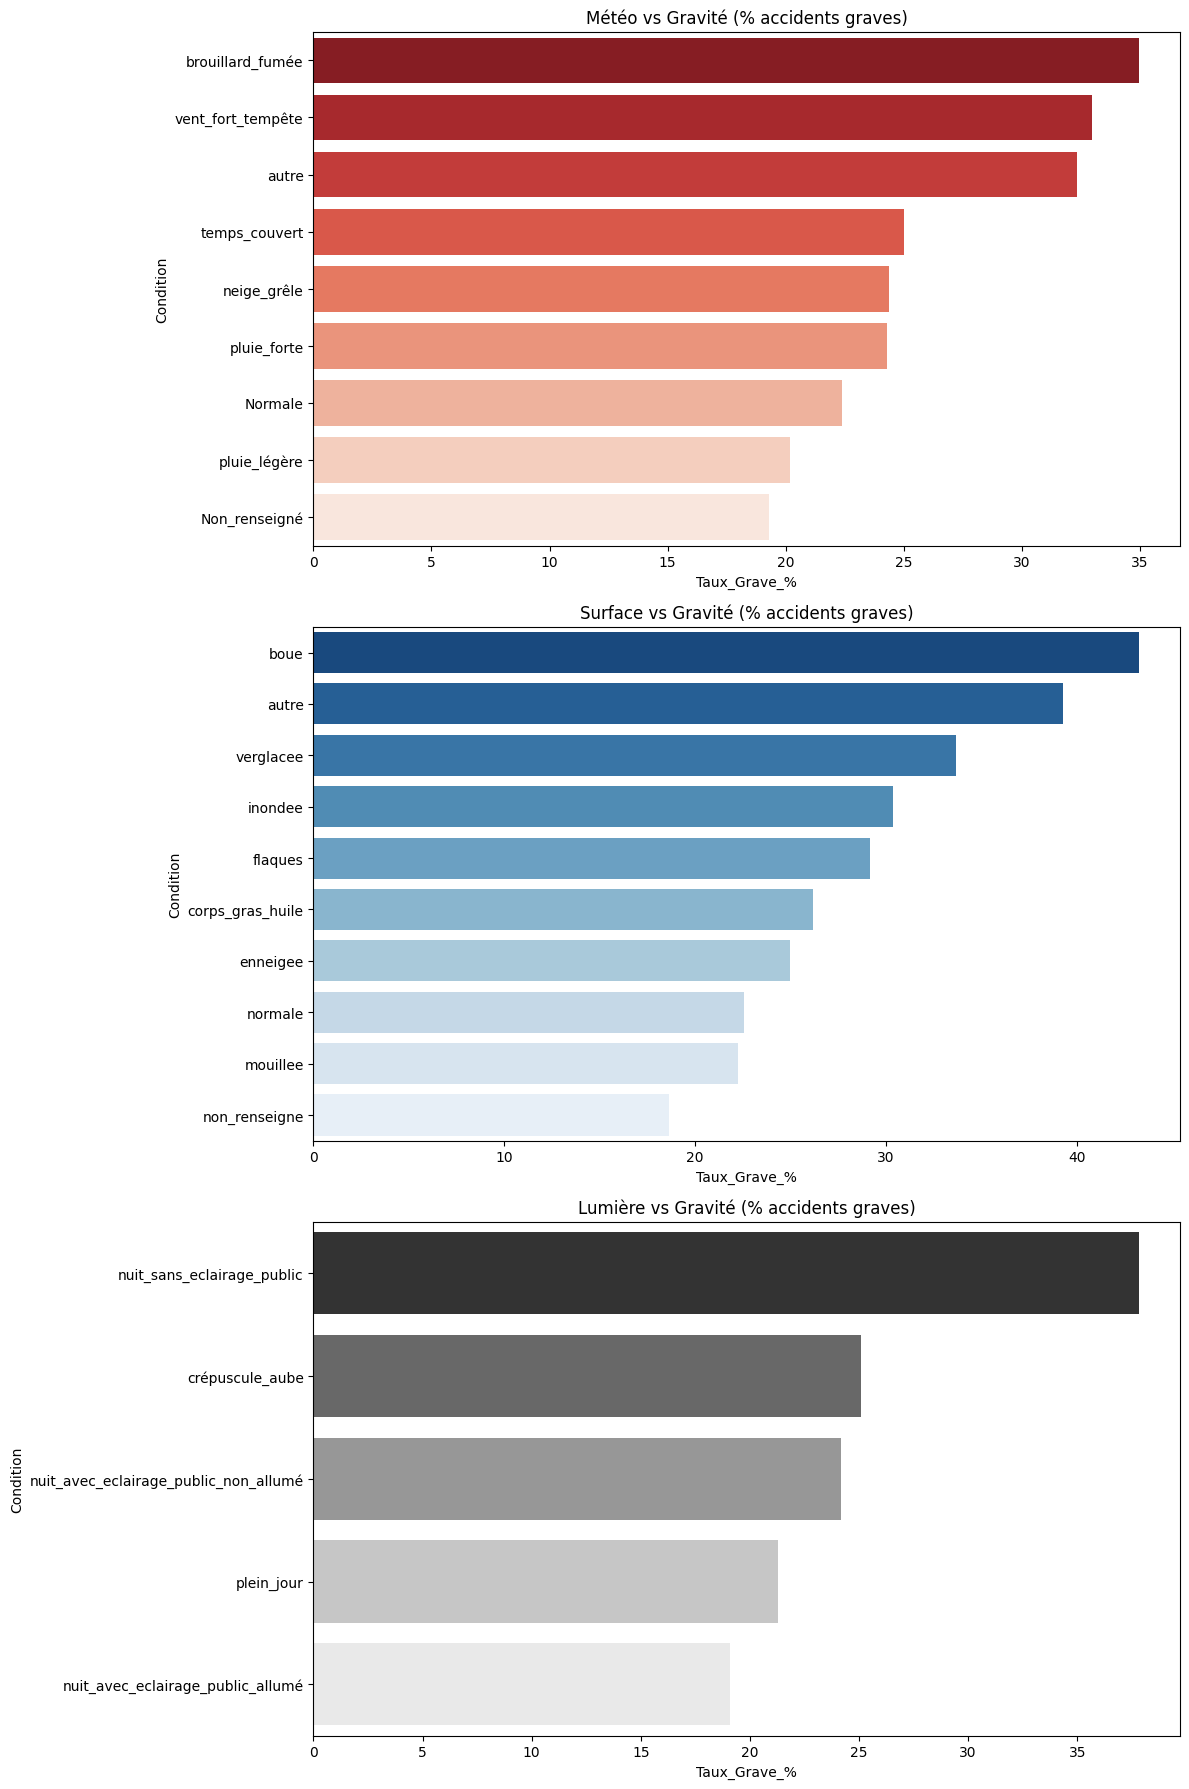

In [405]:
# Affiche les colonnes pour vérifier les noms exacts
print("Colonnes dispo :", [c for c in df_final.columns if '_' in c][:20])

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# A. Météo
df_atm = calcul_taux_grave_safe(df_final, 'atm_')
if not df_atm.empty:
    sns.barplot(data=df_atm, x='Taux_Grave_%', y='Condition', ax=axes[0], palette='Reds_r')
axes[0].set_title('Météo vs Gravité (% accidents graves)')

# B. Surface
df_surf = calcul_taux_grave_safe(df_final, 'surf_')
if not df_surf.empty:
    sns.barplot(data=df_surf, x='Taux_Grave_%', y='Condition', ax=axes[1], palette='Blues_r')
axes[1].set_title('Surface vs Gravité (% accidents graves)')

# C. Luminosité
df_lum = calcul_taux_grave_safe(df_final, 'lum_')
if not df_lum.empty:
    sns.barplot(data=df_lum, x='Taux_Grave_%', y='Condition', ax=axes[2], palette='Greys_r')
else:
    axes[2].text(0.5, 0.5, "Données de luminosité non trouvées", ha='center')
axes[2].set_title('Lumière vs Gravité (% accidents graves)')

plt.tight_layout()
plt.show()

On voit qu'il y a plus d'accidents graves quand les conditions météorologiques sont précaires, mais les écarts ne sont pas énormes.

#### distribution de la gravité

C:\Users\Lucy Neveux\AppData\Local\Temp\ipykernel_22344\2708457403.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='grav_label', order=ordre, palette="viridis")


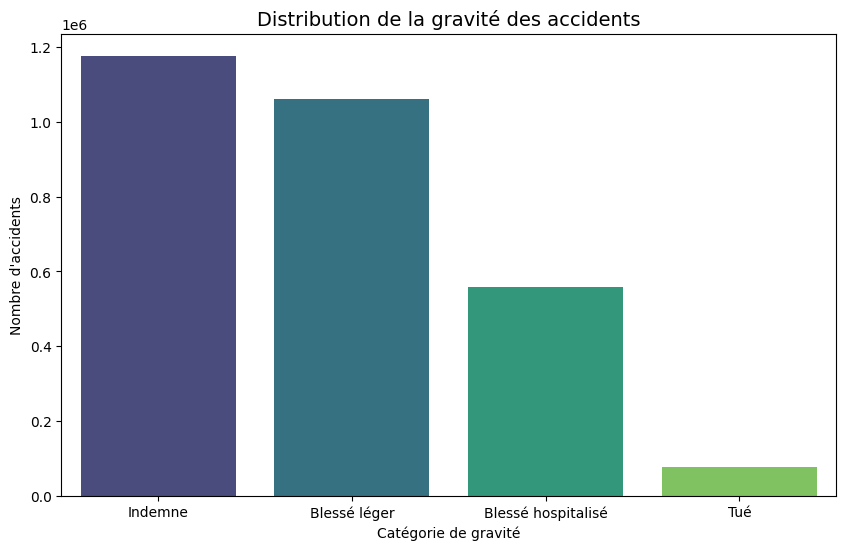

In [406]:
mapping_grav = {1: "Indemne", 2: "Tué", 3: "Blessé hospitalisé", 4: "Blessé léger"}
df_plot = df_final.copy()
df_plot['grav_label'] = df_plot['grav'].map(mapping_grav)

plt.figure(figsize=(10, 6))
ordre = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

sns.countplot(data=df_plot, x='grav_label', order=ordre, palette="viridis")

plt.title("Distribution de la gravité des accidents", fontsize=14)
plt.xlabel("Catégorie de gravité")
plt.ylabel("Nombre d'accidents")
plt.show()

#### profils temporels (heure, mois)

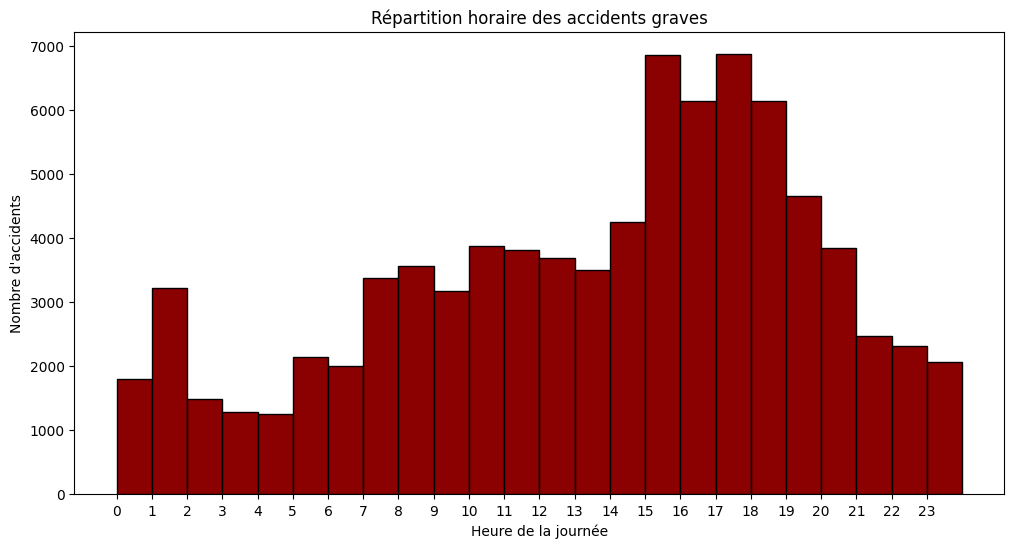

In [407]:
# 1. On filtre pour les accidents graves
df_graves = df_final[df_final['grav'].isin([3, 2])].copy()

# 2. On extrait l'heure en gérant les valeurs manquantes (NaN)
# 'errors=coerce' transforme les erreurs en NaN, puis on les supprime
df_graves['heure_seule'] = pd.to_numeric(df_graves['hrmn'].astype(str).str.split(':').str[0], errors='coerce')
df_graves = df_graves.dropna(subset=['heure_seule'])
df_graves['heure_seule'] = df_graves['heure_seule'].astype(int)

# 3. Histogramme
plt.figure(figsize=(12, 6))
plt.hist(df_graves['heure_seule'], bins=range(25), edgecolor='black', color='darkred')
plt.title("Répartition horaire des accidents graves")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d'accidents")
plt.xticks(range(0, 24))
plt.show()

In [385]:
df_final['heure_seule'] = pd.to_numeric(df_final['hrmn'].astype(str).str.split(':').str[0], errors='coerce').fillna(0).astype(int)

On voit que les accidents graves arrivent en fin d'après-midi et en début de  soirée (sortie de travail, moins de vigilance, alcool), ce qui semble logique.

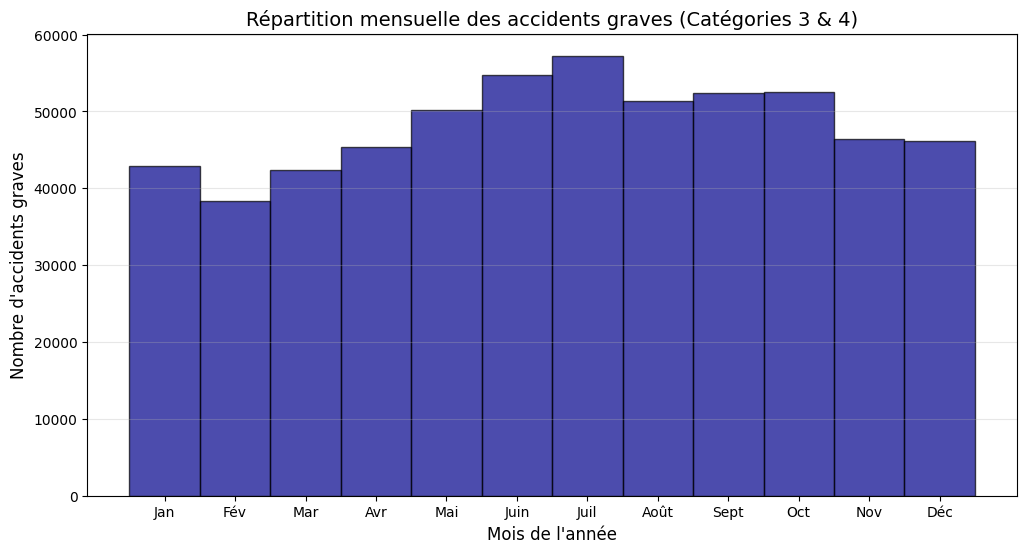

In [408]:
# 1. On filtre pour ne garder que les accidents graves 
df_graves_mois = df_final[df_final['grav'].isin([3, 2])].copy()

# 2. On trace l'histogramme
plt.figure(figsize=(12, 6))
# On utilise bins=range(1, 14) pour bien centrer les 12 mois (de 1 à 12)
plt.hist(df_graves_mois['mois'], bins=range(1, 14), edgecolor='black', color='darkblue', alpha=0.7, align='left')

plt.title("Répartition mensuelle des accidents graves (Catégories 3 & 4)", fontsize=14)
plt.xlabel("Mois de l'année", fontsize=12)
plt.ylabel("Nombre d'accidents graves", fontsize=12)

# On remplace les chiffres par les noms des mois pour la clarté
plt.xticks(range(1, 13), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sept', 'Oct', 'Nov', 'Déc'])
plt.grid(axis='y', alpha=0.3)
plt.show()

Il n'y a pas l'air d'y avoir de saisonalité. Il y a un taux plus été pendant les vacances d'été, sans doute car les conducteurs sont moins vigilants et car ils sont dans des endroits qu'ils connaissent moins. 

#### analyse des âges

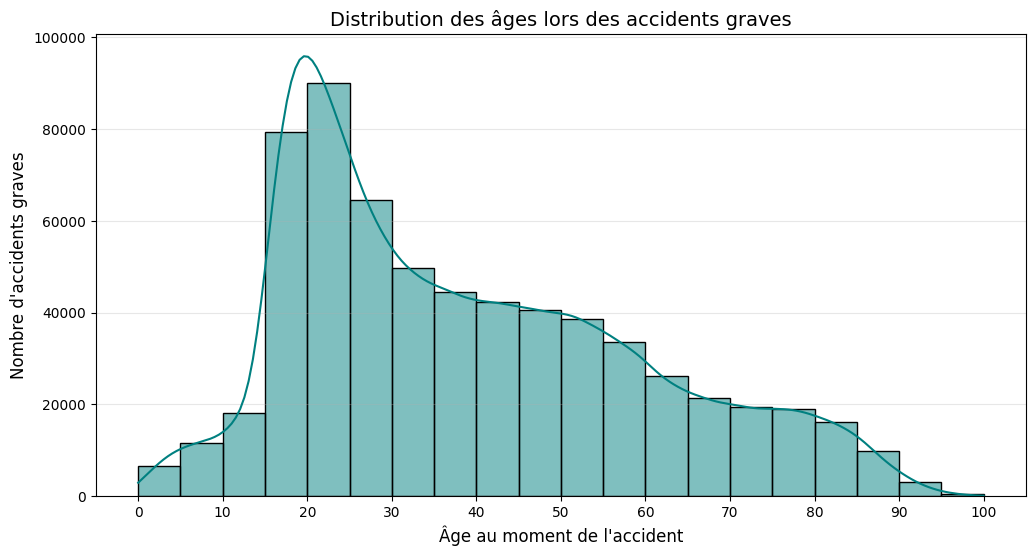

In [409]:
# Calcul dynamique de l'âge au moment de l'accident
if 'an_nais' in df_final.columns and 'year' in df_final.columns:
    # Calcul : Année de l'accident - Année de naissance
    df_final['age'] = df_final['year'] - df_final['an_nais']
    
    # Nettoyage : On supprime les valeurs aberrantes (ex: erreurs de saisie)
    df_final = df_final[(df_final['age'] >= 0) & (df_final['age'] <= 100)]

# Filtrage des accidents graves 
df_graves_age = df_final[df_final['grav'].isin([3, 2])].copy()

# Tracé de l'histogramme
plt.figure(figsize=(12, 6))
sns.histplot(df_graves_age['age'], bins=range(0, 101, 5), kde=True, color='teal', edgecolor='black')

plt.title(f"Distribution des âges lors des accidents graves", fontsize=14)
plt.xlabel("Âge au moment de l'accident", fontsize=12)
plt.ylabel("Nombre d'accidents graves", fontsize=12)
plt.xticks(range(0, 101, 10))
plt.grid(axis='y', alpha=0.3)
plt.show()

Les accidents les plus graves concernent les jeunes, qui sont moins vigilants et moins habitués à conduire.

# Modélisation

### 1. prédiction de grav grâce à : heure, age, mois, atm, lumière, surface

In [388]:
!pip install scikit-learn

In [389]:
# On définit la cible (Y) et les variables explicatives (X)
# On utilise les variables que tu as créées : heure_seule, age, et les dummies
features = ['heure_seule', 'age', 'mois'] + [c for c in df_final.columns if 'atm_' in c or 'surf_' in c or 'lum_' in c]
X = df_final[features]
y = df_final['grav']

In [390]:
from sklearn.model_selection import train_test_split


In [391]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Taille de l'entraînement : {X_train.shape[0]} lignes")

Taille de l'entraînement : 2298592 lignes


In [392]:
from sklearn.ensemble import RandomForestClassifier

In [393]:
# Initialisation du modèle
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Entraînement
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [395]:
from sklearn.metrics import classification_report, confusion_matrix

c:\Users\Lucy Neveux\OneDrive\Documents\GitHub\Predict-Traffic-Accident-Severity\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucy Neveux\OneDrive\Documents\GitHub\Predict-Traffic-Accident-Severity\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucy Neveux\OneDrive\Documents\GitHub\Predict-Traffic-Accident-Severity\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi

              precision    recall  f1-score   support

         1.0       0.45      0.86      0.59    235322
         2.0       0.00      0.00      0.00     15387
         3.0       0.38      0.04      0.07    111481
         4.0       0.48      0.25      0.33    212458

    accuracy                           0.45    574648
   macro avg       0.33      0.29      0.25    574648
weighted avg       0.43      0.45      0.38    574648



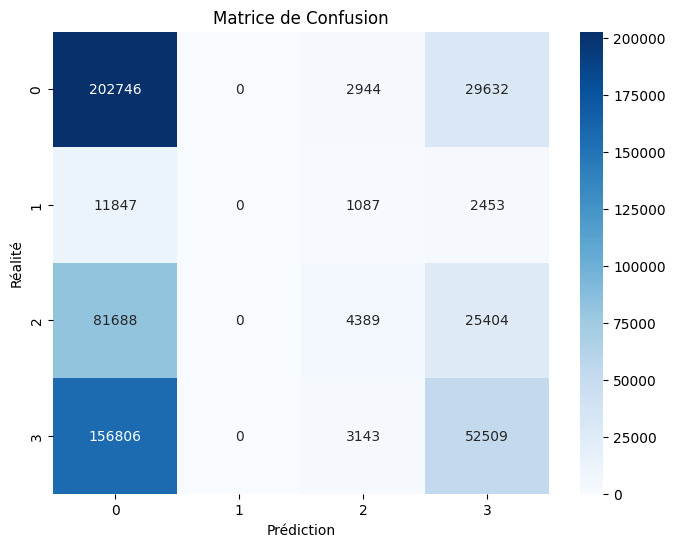

In [396]:
y_pred = rf_model.predict(X_test)

# Affichage du rapport détaillé (Precision, Recall, F1-score)
print(classification_report(y_test, y_pred))

# Matrice de confusion pour voir où le modèle se trompe
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.show()

L'accuracy est de 45%, ce qui n'est pas génial. 
Commen on l'a vu dans la partie Description (distribution de la gravité), il y a plus d'accidents non graves que graves, ce qui justifie pourquoi notre modèle a tendance à se tromper pour tout ce qui n'est pas "indemne".

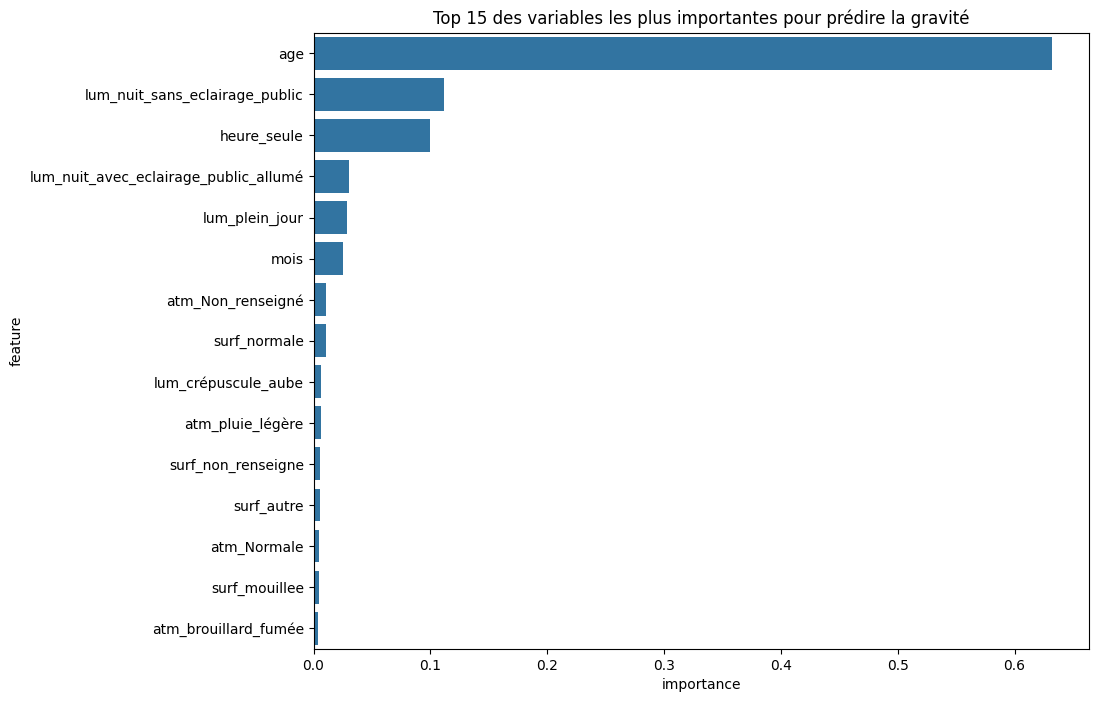

In [397]:
# Récupération de l'importance des features
importances = pd.DataFrame({'feature': features, 'importance': rf_model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='importance', y='feature')
plt.title("Top 15 des variables les plus importantes pour prédire la gravité")
plt.show()

### 2. Amélioration du modèle précédent - random forest 'balanced'

In [398]:
from sklearn.ensemble import RandomForestClassifier

In [399]:
features = ['heure_seule', 'age', 'mois'] + [c for c in df_final.columns if 'atm_' in c or 'surf_' in c or 'lum_' in c]

X = df_final[features]
y = df_final['grav']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


--- Nouveau Rapport de Classification (Équilibré) ---


c:\Users\Lucy Neveux\OneDrive\Documents\GitHub\Predict-Traffic-Accident-Severity\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucy Neveux\OneDrive\Documents\GitHub\Predict-Traffic-Accident-Severity\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucy Neveux\OneDrive\Documents\GitHub\Predict-Traffic-Accident-Severity\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples.

              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00         0
         1.0       0.47      0.59      0.53    235322
         2.0       0.07      0.46      0.12     15387
         3.0       0.29      0.10      0.15    111481
         4.0       0.45      0.28      0.34    212458

    accuracy                           0.38    574648
   macro avg       0.26      0.29      0.23    574648
weighted avg       0.42      0.38      0.38    574648



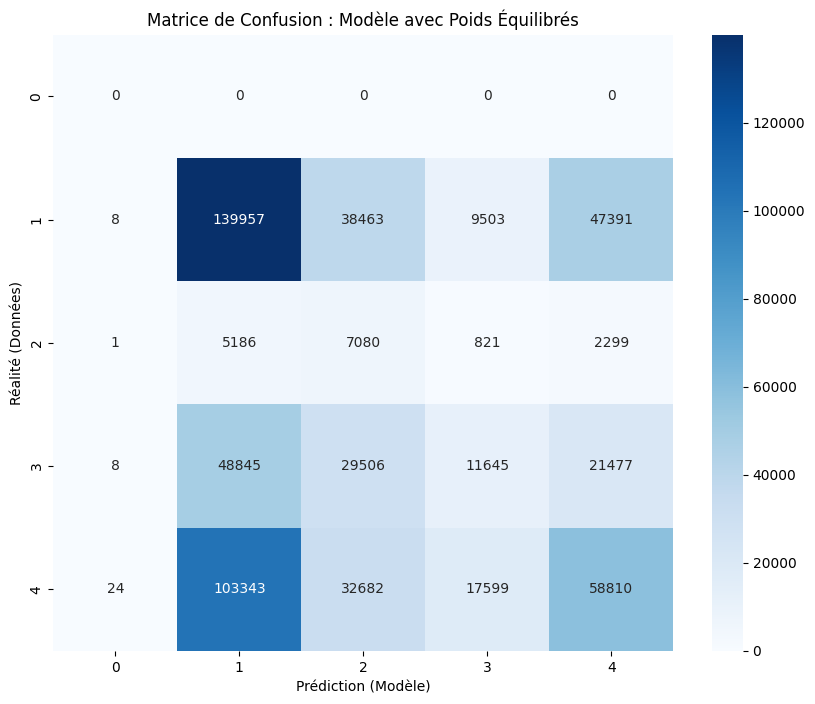

In [402]:
y_pred = model_rf.predict(X_test)
print("\n--- Nouveau Rapport de Classification (Équilibré) ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion : Modèle avec Poids Équilibrés')
plt.xlabel('Prédiction (Modèle)')
plt.ylabel('Réalité (Données)')
plt.show()

On voit que l'accuracy a baissé, mais il prédit mieux les accidents plus graves.

### 3. Autre amélioration - deux classes de gravité au lieu d'une 

In [410]:
df_binaire = df_final.copy()
df_binaire = df_binaire[df_binaire['grav'] > 0]
mapping = {1.0: 0, 4.0: 0, 2.0: 1, 3.0: 1}
df_binaire['grav_bin'] = df_binaire['grav'].map(mapping)

In [411]:
features = ['heure_seule', 'age', 'mois'] + [c for c in df_binaire.columns if 'atm_' in c or 'surf_' in c or 'lum_' in c]
X = df_binaire[features]
y = df_binaire['grav_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_bin = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
model_bin.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

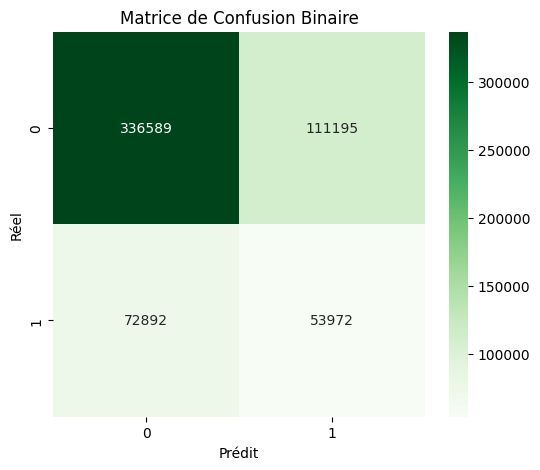

In [ ]:

y_pred = model_bin.predict(X_test)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de Confusion Binaire')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

In [413]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.75      0.79    447784
           1       0.33      0.43      0.37    126864

    accuracy                           0.68    574648
   macro avg       0.57      0.59      0.58    574648
weighted avg       0.71      0.68      0.69    574648



Comme on pouvait s'y attendre, les résultats sont meilleurs, mais on a perdu beaucoup de précision.